In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2

In [2]:
img = image.load_img(r"D:\ABHI-VSCODE\4.DEEPLEARNING\Traning\Happy\happy_01.jpg")


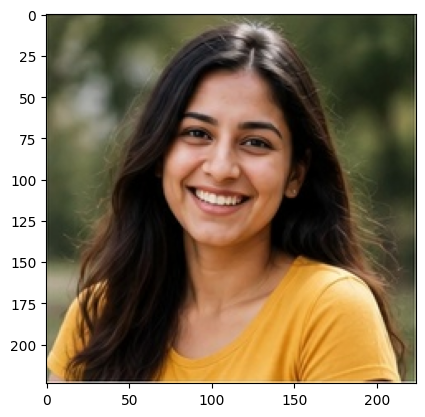

In [3]:
plt.imshow(img)

In [4]:
i1 =cv2.imread(r'D:\ABHI-VSCODE\4.DEEPLEARNING\Traning\Happy\happy_01.jpg')
i1

array([[[137, 160, 156],
        [ 99, 122, 118],
        [109, 134, 130],
        ...,
        [ 93, 114, 105],
        [ 76,  93,  84],
        [154, 171, 162]],

       [[ 79, 102,  98],
        [ 38,  63,  59],
        [ 49,  74,  70],
        ...,
        [ 37,  58,  49],
        [ 21,  40,  31],
        [106, 123, 114]],

       [[ 93, 118, 114],
        [ 53,  78,  74],
        [ 63,  88,  84],
        ...,
        [ 50,  71,  62],
        [ 34,  53,  44],
        [117, 136, 127]],

       ...,

       [[123, 138, 147],
        [125, 142, 155],
        [165, 181, 204],
        ...,
        [ 90, 131, 123],
        [ 79, 116, 108],
        [140, 176, 170]],

       [[110, 128, 135],
        [125, 143, 154],
        [156, 169, 191],
        ...,
        [ 87, 118, 109],
        [ 79, 105,  99],
        [136, 162, 156]],

       [[181, 201, 206],
        [193, 212, 220],
        [201, 212, 234],
        ...,
        [181, 206, 196],
        [174, 196, 191],
        [208, 228, 223]]

In [5]:
i1.shape

(224, 224, 3)

In [6]:
train = ImageDataGenerator(rescale=1/200)
validation = ImageDataGenerator(rescale=1/200)

# to scale all the images i need to devided with 255
# we need to resize 255 ,255 pixel

In [7]:
train_dataset = train.flow_from_directory(r'D:\ABHI-VSCODE\4.DEEPLEARNING\Traning',
                                          target_size=(200,200),
                                          batch_size=32,
                                          class_mode='binary')
Validation_dataset =validation.flow_from_directory(r'D:\ABHI-VSCODE\4.DEEPLEARNING\Validation',
                                                   target_size=(200,200),
                                                   batch_size=32,
                                                   class_mode='binary')

Found 30 images belonging to 2 classes.
Found 0 images belonging to 2 classes.


In [8]:
train_dataset.class_indices

{'Happy': 0, 'Not Happy': 1}

In [9]:
train_dataset.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1])

In [10]:
# now we are applying maxpooling

import tensorflow as tf
model =tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16,(3,3),activation='relu',input_shape=(200,200,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])
model.summary()

c:\Users\abhis\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    17,334,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,358,881 (66.22 MB)

 Trainable params: 17,358,881 (66.22 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [12]:
model_fit = model.fit(train_dataset,epochs = 8)

Epoch 1/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5000 - loss: 0.6940
Epoch 2/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.5000 - loss: 3.7762
Epoch 3/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 833ms/step - accuracy: 0.7333 - loss: 0.5446
Epoch 4/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 798ms/step - accuracy: 0.6333 - loss: 0.6849
Epoch 5/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step - accuracy: 0.9000 - loss: 0.3622
Epoch 6/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.7333 - loss: 0.4140
Epoch 7/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step - accuracy: 0.9333 - loss: 0.2752
Epoch 8/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.9333 - loss: 0.2321


In [13]:
dir_path = r"D:\ABHI-VSCODE\4.DEEPLEARNING\Testing"
for i in os.listdir(dir_path):
  #img = image.load_img(dir_path+'//'+i,target_size=(200,200))
  print(i)

happy_01.jpg
happy_02.jpg
happy_03.jpg
happy_04.jpg
sad_01.jpg
sad_02.jpg
sad_03.jpg
sad_04.jpg


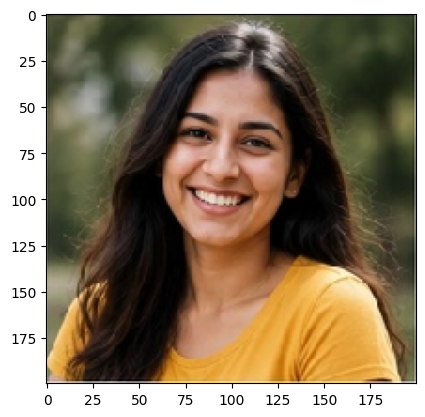

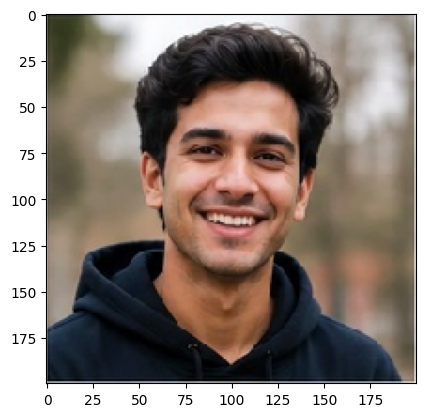

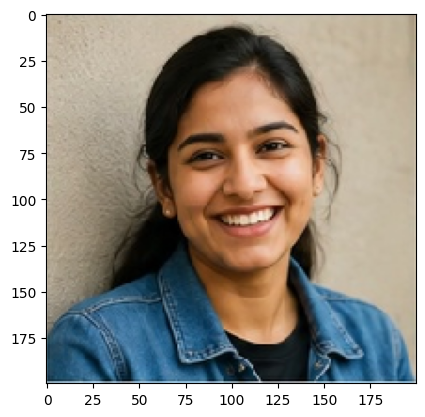

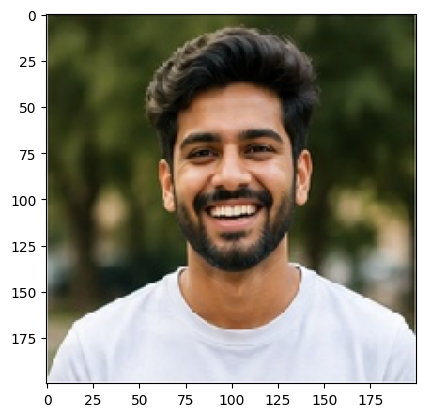

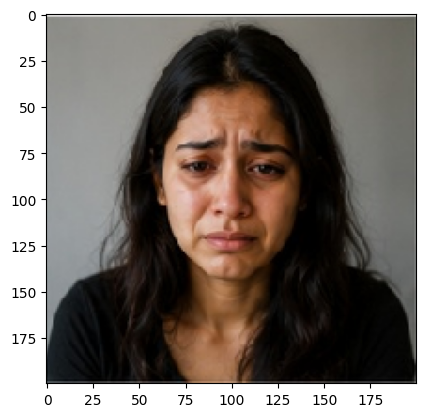

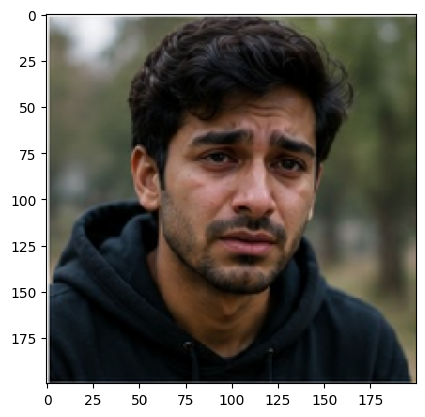

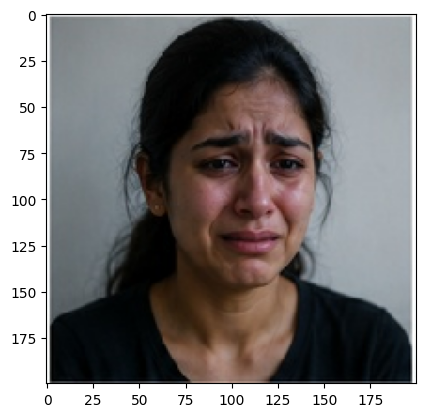

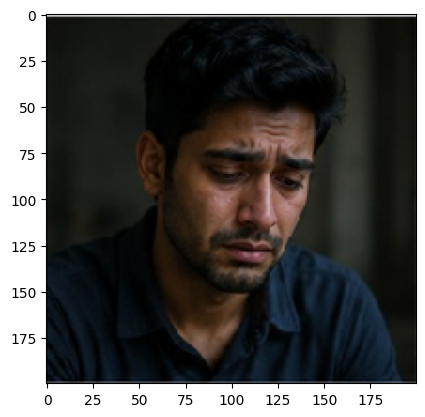

In [14]:
dir_path = r"D:\ABHI-VSCODE\4.DEEPLEARNING\Testing"
for i in os.listdir(dir_path):
    img = image.load_img(os.path.join(dir_path, i), target_size=(200,200))
    plt.imshow(img)
    plt.show()

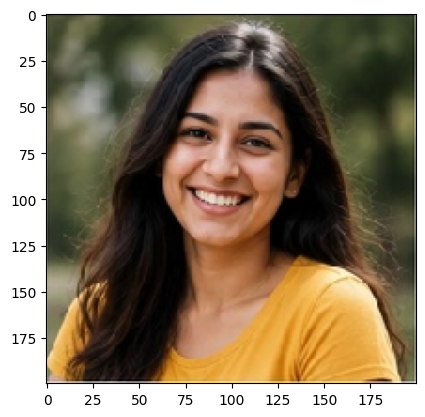

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
i am Happy


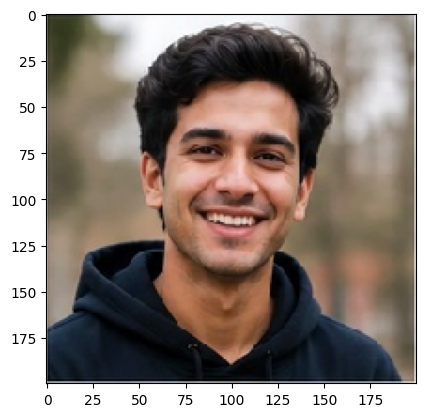

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
i ama not Happy


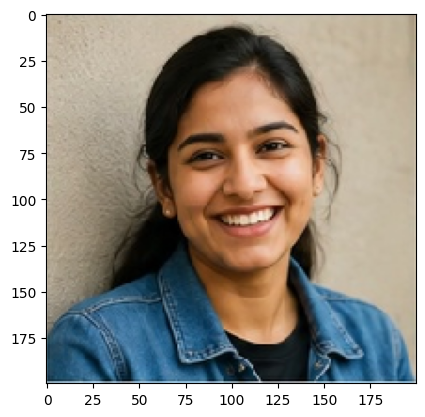

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
i am Happy


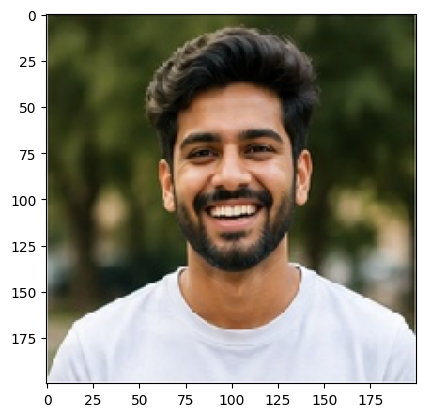

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
i am Happy


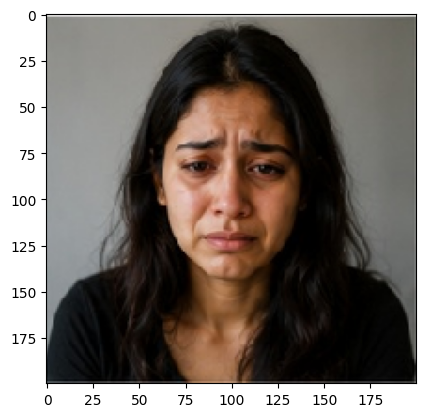

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
i ama not Happy


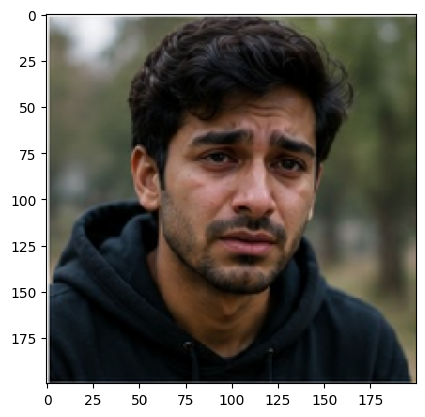

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
i ama not Happy


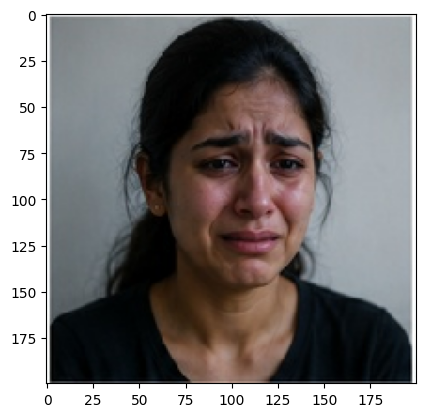

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
i ama not Happy


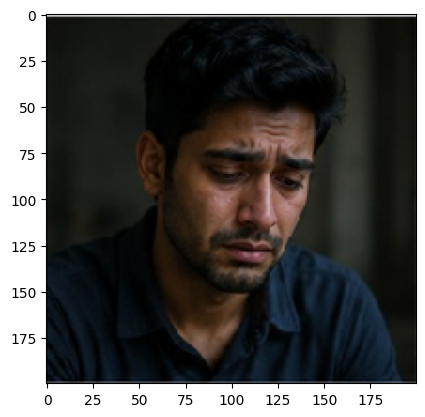

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
i ama not Happy


In [15]:
dir_path =r"D:\ABHI-VSCODE\4.DEEPLEARNING\Testing"

for i in os.listdir(dir_path):
  img = image.load_img(dir_path+'//'+i,target_size=(200,200))
  plt.imshow(img)
  plt.show()

  X = image.img_to_array(img)
  X = np.expand_dims(X,axis=0)
  images = np.vstack([X])

  val = model.predict(images)
  if val == 0:
    print("i am Happy")
  else:
    print("i ama not Happy")

In [16]:
#!pip install gradio


In [17]:
#import sys
#!{sys.executable} -m pip install gradio


In [18]:
# import gradio as gr
# from PIL import Image
# import numpy as np

# def predict_mood(image):
#   # Resize the image to (200,200) as expected by the model
#   img = image.resize((200,200))

#   # Convert the image to a numpy array
#   x = np.array(img)

#   # Expand the dimensions of the array to match the expected input shape of the model
#   x = np.expand_dims(x , axis=0)
#   # Normalize the image  (if the model was trained with normalize inputs)
#   # The model was trained with rescale=1/200 ,so we should apply the same scalling here
#   x = x/200.0
#   # Make prediction
#   val = model.presict(x)[0][0]
#   # Interpret the prediction
#   if val < 0.5:
#     return 'Happy'
#   else:
#     return 'Not Happy'

In [19]:
# import gradio as gr
# from PIL import Image
# import numpy as np

# def predict_mood(image):
#     # Resize the image to (200,200) as expected by the model
#     img = image.resize((200,200))

#     # Convert the image to a numpy array
#     x = np.array(img)

#     # Expand dimensions to match model input shape
#     x = np.expand_dims(x, axis=0)

#     # Normalize (since model was trained with rescale=1/200)
#     x = x / 200.0

#     # Make prediction
#     val = model.predict(x)[0][0]   # ✅ fixed typo

#     # Interpret the prediction
#     if val < 0.5:
#         return 'Happy'
#     else:
#         return 'Not Happy'


In [20]:
import gradio as gr
from PIL import Image
import numpy as np

def predict_mood(image):
    # Resize the image to (200,200) as expected by the model
    img = image.resize((200,200))

    # Convert the image to a numpy array
    x = np.array(img)

    # Expand dimensions to match model input shape
    x = np.expand_dims(x, axis=0)

    # Normalize (since model was trained with rescale=1/200)
    x = x / 200.0

    # Make prediction
    val = model.predict(x)[0][0]

    # Interpret the prediction with BIG emoji
    if val < 0.5:
        return "<span style='font-size:60px'>🙂 Happy</span>"
    else:
        return "<span style='font-size:60px'>🙁 Not Happy</span>"

# Gradio interface with HTML output
demo = gr.Interface(
    fn=predict_mood,
    inputs=gr.Image(type="pil"),
    outputs=gr.HTML()
)

demo.launch()


c:\Users\abhis\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [ ]:
iface = gr.Interface(fn=predict_mood,
                     inputs=gr.Image(type="pil",label="Upload an image"),
                     outputs=gr.Textbox(label="Predicted Mood"),
                     title = "Mood Classification (Happy/Not Happy)",
                     description="Upload an image classify if the person is happy or not happy.")
iface.launch(debug=True)

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step
